
### 本次项目主要分为一下三个核心步骤
1. 数据预处理：加载CSV、归一化、划分验证集、构建DataLoader
2. 模型构建与训练：搭建三层全连接网络、设定损失函数与优化器、训练循环
3. 验证与预测提交：在验证集评估模型、预测测试集、生成提交文件

In [10]:
# 下载数据集
import kagglehub

path = kagglehub.competition_download('digit-recognizer', output_dir='./data', force_download=True)

print("Path to competition files:", path)

100%|██████████| 15.3M/15.3M [00:01<00:00, 11.8MB/s]

Extracting files...


Path to competition files: ./data


In [11]:
# 导入本次训练所需要的库
import torch # 导入 PyTorch 库
import torch.nn as nn # 导入神经网络模块
import torch.optim as optim # 导入优化器模块
from torch.utils.data import DataLoader, Dataset # 导入数据加载器和数据集模块
import pandas as pd # 导入 Pandas 库用于数据处理
import numpy as np # 导入 NumPy 库用于数值计算
import matplotlib.pyplot as plt # 导入 Matplotlib 库用于数据可视化
# 切分训练集和验证集    
from sklearn.model_selection import train_test_split # 导入 train_test_split 函数用于切分数据集



In [12]:
# 读取训练数据                                                                                                                                           
train = pd.read_csv('./data/train.csv')                                                                                                                         
test = pd.read_csv('./data/test.csv')                                                                                                                           
                                                                                                                                                          
# 查看数据前几行                                                                                                                                         
print("训练数据前5行:\n" + str(train.head()))                                                                                                                                      
print("训练数据维度: " + str(train.shape))  # 查看数据维度                                                                                                                       
print("训练数据信息:\n" + str(train.info()))  # 查看列信息和类型  

训练数据前5行:
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0

In [13]:
# 数据预处理
train_labels = train['label'].values # 提取标签列
train_images = train.drop('label', axis=1).values # 提取像素列并转换为 NumPy 数组
print("标签数据的维度: " + str(train_labels.shape))  # 查看标签数据的维度
print("图像数据的维度: " + str(train_images.shape))  # 查看图像数据的维度
print("像素值的最大值: " + str(train_images.max()))  # 查看像素值的最大值
print("像素值的最小值: " + str(train_images.min()))  # 查看像素值的最小值
train_images = train_images / 255.0  # 将像素值归一化到 [0, 1] 范围
print("归一化后像素值的最大值: " + str(train_images.max()))  # 查看归一化后的最大值
print("归一化后像素值的最小值: " + str(train_images.min()))  # 查看归一化后的最小值

标签数据的维度: (42000,)
图像数据的维度: (42000, 784)
像素值的最大值: 255
像素值的最小值: 0
归一化后像素值的最大值: 1.0
归一化后像素值的最小值: 0.0


In [14]:
# 切分训练集和验证集    
X_train, X_val, y_train, y_val = train_test_split(train_images, train_labels, test_size=0.2, random_state=42) # 切分训练集和验证集，比例为 8:2
# 查看切分后的数据维度
print("训练集图像数据维度: " + str(X_train.shape))  # 查看训练集图像数据维度
# 转为 PyTorch 张量
X_train = torch.tensor(X_train, dtype=torch.float32) # 将训练集图像数据转换为 PyTorch 张量
y_train = torch.tensor(y_train, dtype=torch.long) # 将训练集标签数据转换为 PyTorch 张量
X_val = torch.tensor(X_val, dtype=torch.float32) # 将验证集图像数据转换为 PyTorch 张量
y_val = torch.tensor(y_val, dtype=torch.long) # 将验证集标签数据转换为 PyTorch 张量
print("训练集图像数据张量维度: " + str(X_train.shape))  # 查看训练集图像数据张量维度
print("验证集图像数据张量维度: " + str(X_val.shape))  # 查看验证集图像数据张量维度
# 创建tensor数据集
train_dataset = torch.utils.data.TensorDataset(X_train, y_train) # 创建训练集的 TensorDataset
val_dataset = torch.utils.data.TensorDataset(X_val, y_val) # 创建验证集的 TensorDataset
# 创建数据加载器
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

训练集图像数据维度: (33600, 784)
训练集图像数据张量维度: torch.Size([33600, 784])
验证集图像数据张量维度: torch.Size([8400, 784])


In [15]:
# 定义网络模型
model = nn.Sequential(
    nn.Linear(784, 128), # 输入层到隐藏层的线性变换，输入维度为 784，输出维度为 128
    nn.ReLU(), # 激活函数 ReLU
    nn.Linear(128, 64), # 隐藏层到隐藏层的线性变换，输入维度为 128，输出维度为 64
    nn.ReLU(), # 激活函数 ReLU
    nn.Linear(64, 10) # 隐藏层到输出层的线性变换，输入维度为 64，输出维度为 10（对应 10 个数字类别）
)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss() # 使用交叉熵损失函数
optimizer = optim.Adam(model.parameters(), lr=0.001) # 使用 Adam 优化器

# 训练模型
num_epochs = 30 # 设置训练轮数为 30
losses = [] # 初始化一个空列表用于存储每轮的损失值
for epoch in range(num_epochs): # 遍历每一轮训练
    model.train() # 设置模型为训练模式
    running_loss = 0.0 # 初始化运行损失
    for images, labels in train_loader: # 遍历训练数据加载器
        optimizer.zero_grad() # 清空梯度
        outputs = model(images) # 前向传播计算输出
        loss = criterion(outputs, labels) # 计算损失
        loss.backward() # 反向传播计算梯度
        optimizer.step() # 更新模型参数
        running_loss += loss.item() # 累加损失值
    losses.append(loss.item()) # 将当前损失值添加到 losses 列表中
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}") # 打印每轮的平均损失


Epoch [1/30], Loss: 0.4349
Epoch [2/30], Loss: 0.1786
Epoch [3/30], Loss: 0.1263
Epoch [4/30], Loss: 0.0954
Epoch [5/30], Loss: 0.0748
Epoch [6/30], Loss: 0.0596
Epoch [7/30], Loss: 0.0459
Epoch [8/30], Loss: 0.0384
Epoch [9/30], Loss: 0.0293
Epoch [10/30], Loss: 0.0265
Epoch [11/30], Loss: 0.0208
Epoch [12/30], Loss: 0.0189
Epoch [13/30], Loss: 0.0156
Epoch [14/30], Loss: 0.0130
Epoch [15/30], Loss: 0.0074
Epoch [16/30], Loss: 0.0061
Epoch [17/30], Loss: 0.0159
Epoch [18/30], Loss: 0.0120
Epoch [19/30], Loss: 0.0082
Epoch [20/30], Loss: 0.0083
Epoch [21/30], Loss: 0.0091
Epoch [22/30], Loss: 0.0091
Epoch [23/30], Loss: 0.0035
Epoch [24/30], Loss: 0.0012
Epoch [25/30], Loss: 0.0127
Epoch [26/30], Loss: 0.0089
Epoch [27/30], Loss: 0.0037
Epoch [28/30], Loss: 0.0049
Epoch [29/30], Loss: 0.0081
Epoch [30/30], Loss: 0.0095


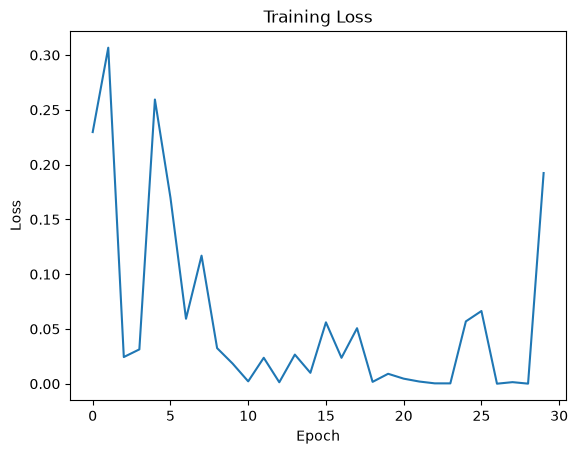

In [16]:
# 可视化损失函数
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [17]:
# 评估模型
model.eval() # 设置模型为评估模式
with torch.no_grad(): # 在评估时不计算梯度
    val_outputs = model(X_val) # 计算验证集的输出
    _, predicted = torch.max(val_outputs, 1) # 获取预测结果
    accuracy = (predicted == y_val).float().mean() # 计算准确率
    print(f"Validation Accuracy: {accuracy:.4f}") # 打印验证集的准确率
# 预测测试集
test_images = test.values / 255.0 # 将测试集图像数据归一化
test_images = torch.tensor(test_images, dtype=torch.float32) # 将测试集图像数据转换为 PyTorch 张量
with torch.no_grad(): # 在预测时不计算梯度
    test_outputs = model(test_images) # 计算测试集的输出
    _, test_predicted = torch.max(test_outputs, 1) # 获取测试集的预测结果
# 创建提交文件
submission = pd.DataFrame({'ImageId': np.arange(1, len(test_predicted) + 1), 'Label': test_predicted.numpy()}) # 创建一个 DataFrame 用于提交，包含 ImageId 和 Label 列
submission.to_csv('submission.csv', index=False) # 将提交文件保存为 submission.csv
print("Submission file created: submission.csv") # 打印提交文件创建成功的消息

Validation Accuracy: 0.9732
Submission file created: submission.csv
